# Classical Machine Learning: Part 1
## Linear Regression Model ( using California Housing Dataset)

### Assumptions under Linear Regression:
- Linearity: Linear relationship between features and target.
- Independence: Observations are independent.
- Normality: Residuals are normally distributed.
- Homoscedasticity: Residuals have constant variance.
- No multicollinearity: Features are not highly correlated with each other.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
california=fetch_california_housing()
X=pd.DataFrame(california.data, columns=california.feature_names)
y=california.target

data=X.copy()
data['medHouseVal']=y

In [5]:
print("Dataset info:")
print(data.info())
print()
print('First 5 entries:')
print(data.head())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   medHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

First 5 entries:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.5479

In [6]:
print("Summary Statistics: ")
print(data.describe())

Summary Statistics: 
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   medHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

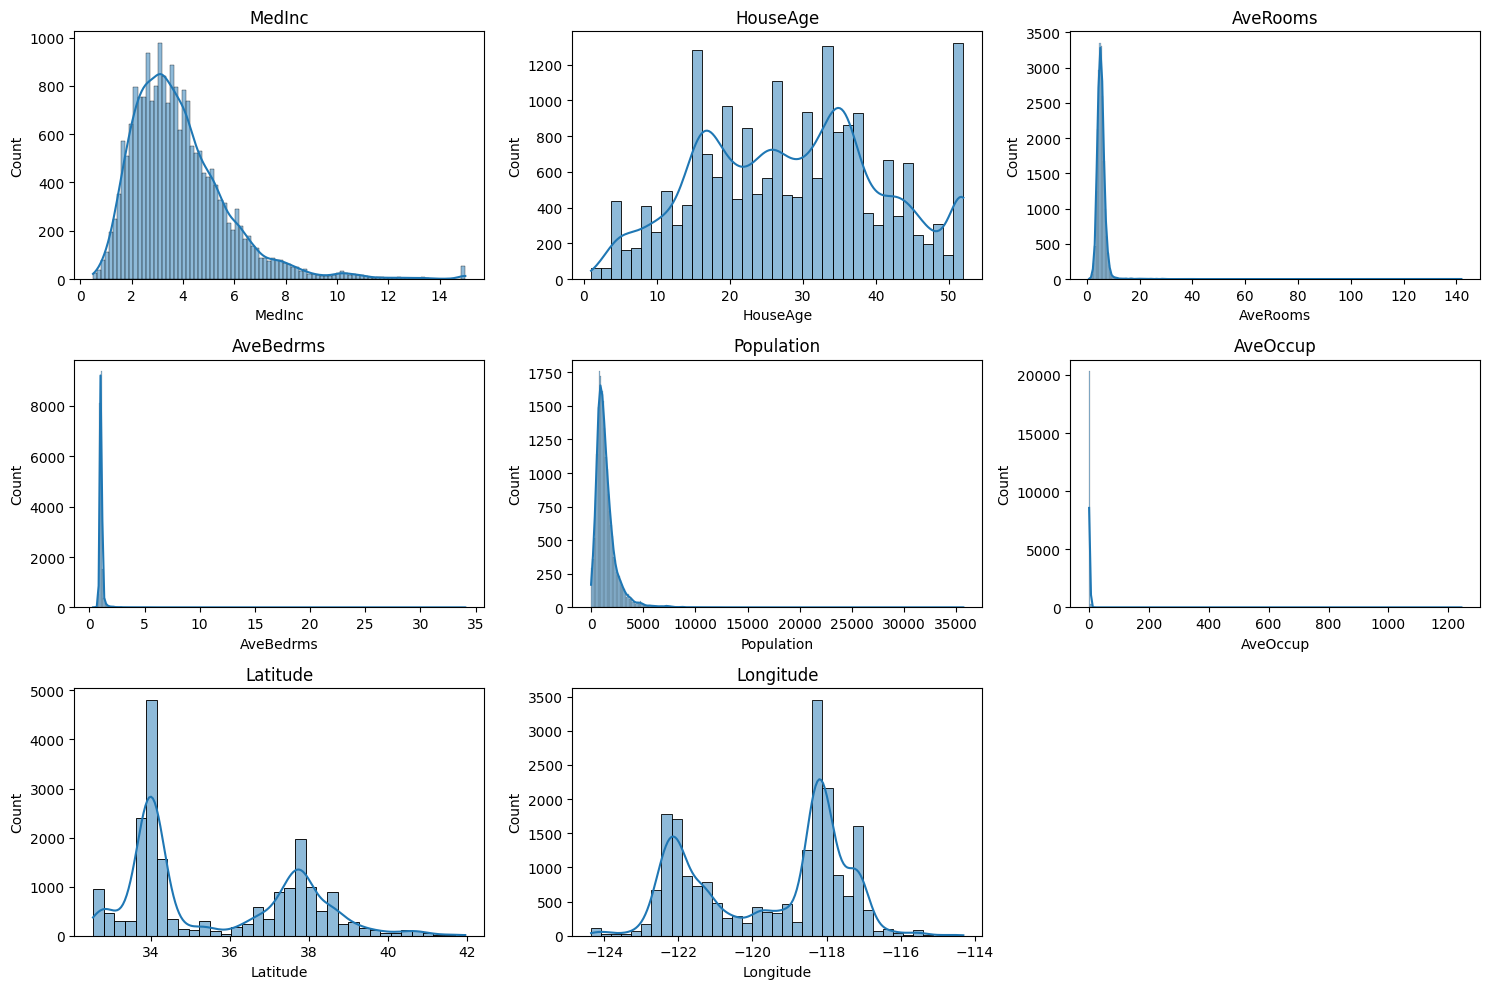

In [7]:
# Feature Distributions
plt.figure(figsize=(15,10))

for i,col in enumerate(X.columns,1):
    plt.subplot(3,3,i)
    sns.histplot(data[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

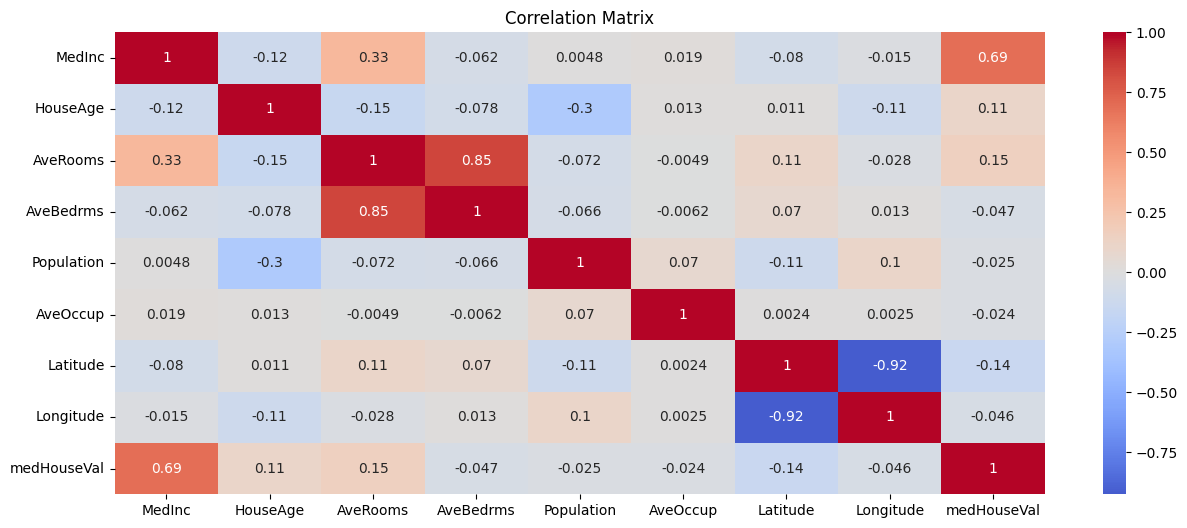

In [8]:
# Correlation HeatMap
plt.figure(figsize=(15,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

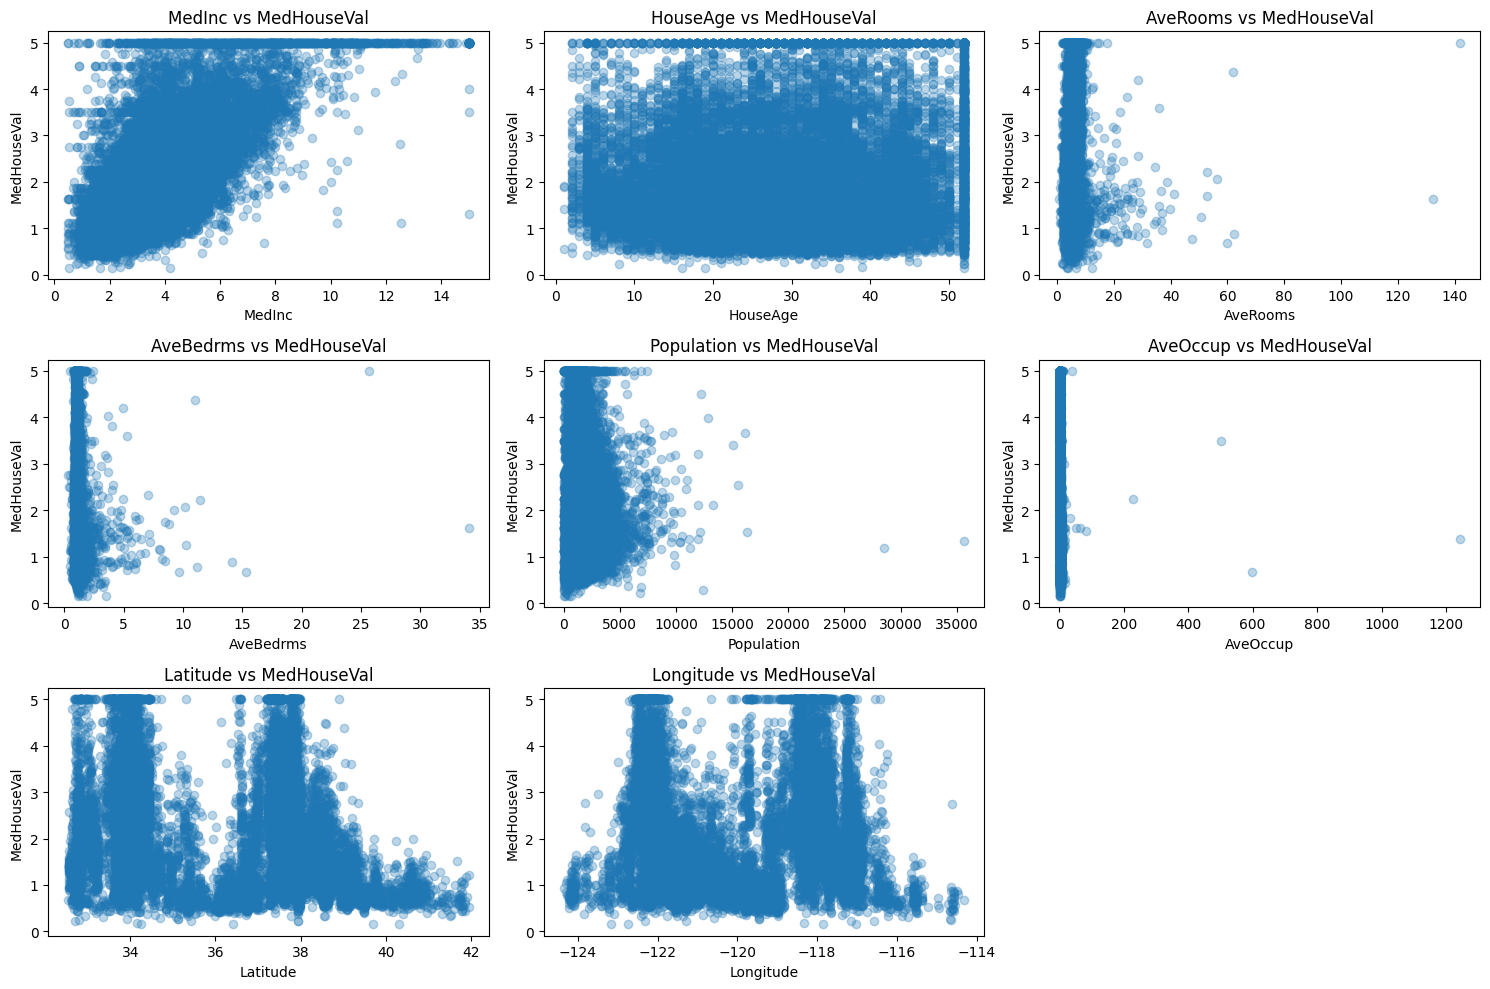

In [9]:
plt.figure(figsize=(15,10))
for i,col in enumerate(X.columns,1):
    plt.subplot(3,3,i)
    plt.scatter(data[col],data['medHouseVal'],alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('MedHouseVal')
    plt.title(f'{col} vs MedHouseVal')
plt.tight_layout()
plt.show()

In [13]:
# Multicollinearity Check
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data=pd.DataFrame()
vif_data['Feature']=X.columns
vif_data['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


In [14]:
# Splitting data
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [16]:
# Initialize and fit the model
model=LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred=model.predict(X_test_scaled)

In [17]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test,y_pred)

print("Model performance:")
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R2 Score: {r2_score:.2f}')

Model performance:
Root Mean Squared Error: 0.73
R2 Score: 0.59


In [18]:
coef_df=pd.DataFrame({
    'Feature':X.columns,
    'Coefficients':model.coef_
})

print('Model coefficients:')
print(coef_df)

Model coefficients:
      Feature  Coefficients
0      MedInc      0.854383
1    HouseAge      0.122546
2    AveRooms     -0.294410
3   AveBedrms      0.339259
4  Population     -0.002308
5    AveOccup     -0.040829
6    Latitude     -0.896929
7   Longitude     -0.869842


In [21]:
# Extract MedInc from test data
med_inc_test=X_test['MedInc'].values
y_test_pred=model.predict(X_test_scaled)

single_feature_model=LinearRegression()
single_feature_model.fit(X_train[['MedInc']],y_train)
y_pred_single=single_feature_model.predict(X_test[['MedInc']])

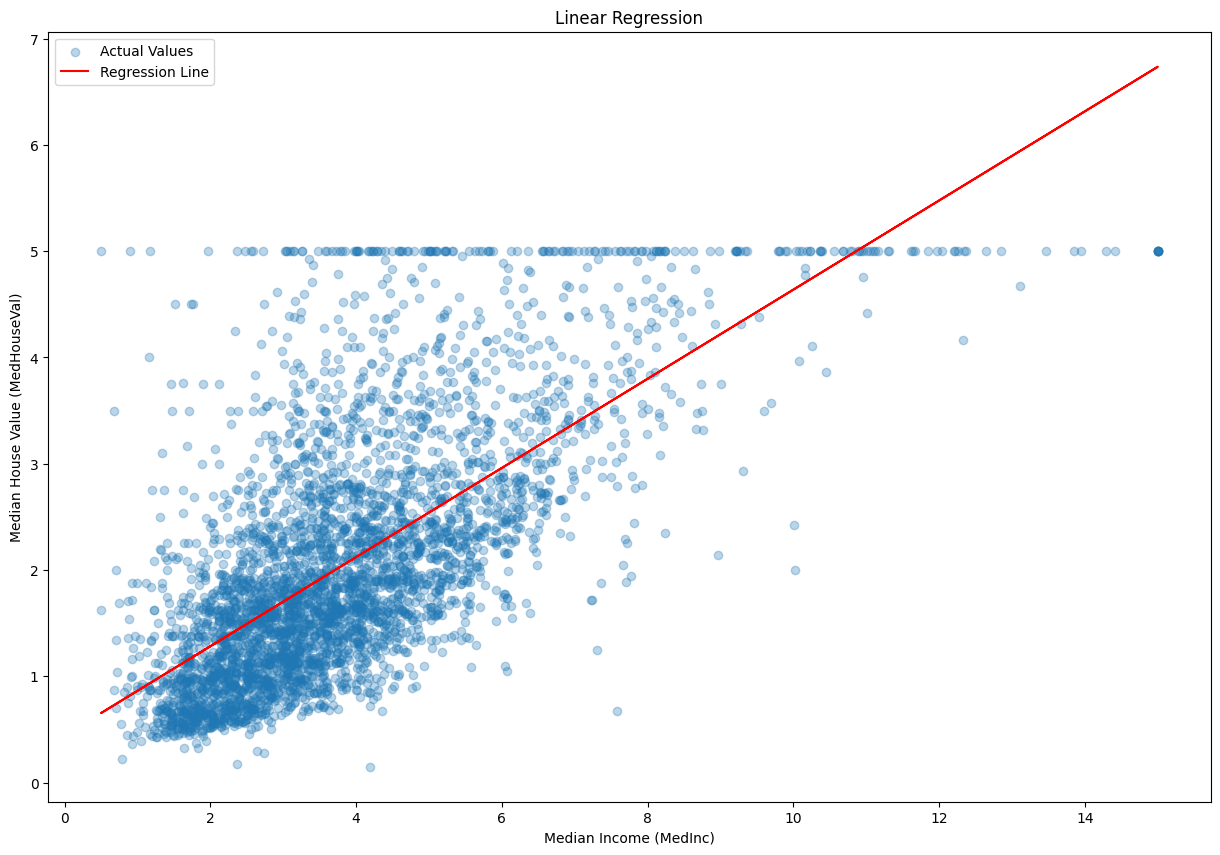

In [23]:
plt.figure(figsize=(15,10))
plt.scatter(med_inc_test, y_test, alpha=0.3, label='Actual Values')
plt.plot(med_inc_test, y_pred_single, color='red', label='Regression Line')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Linear Regression')
plt.legend()
plt.show()

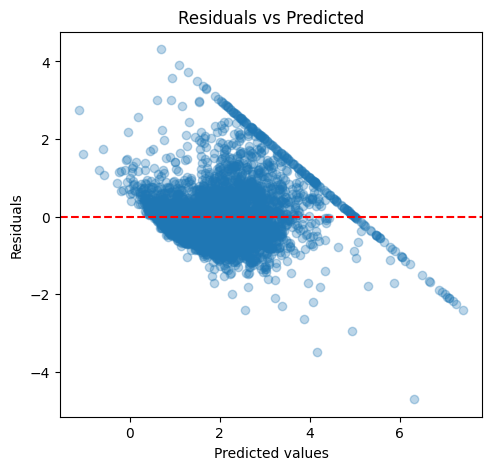

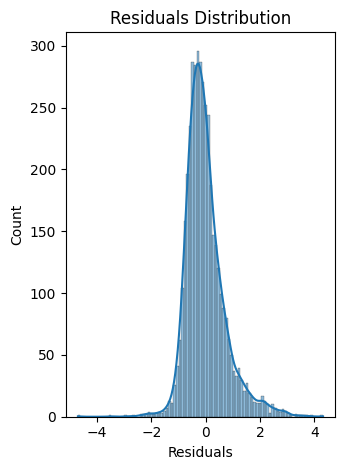

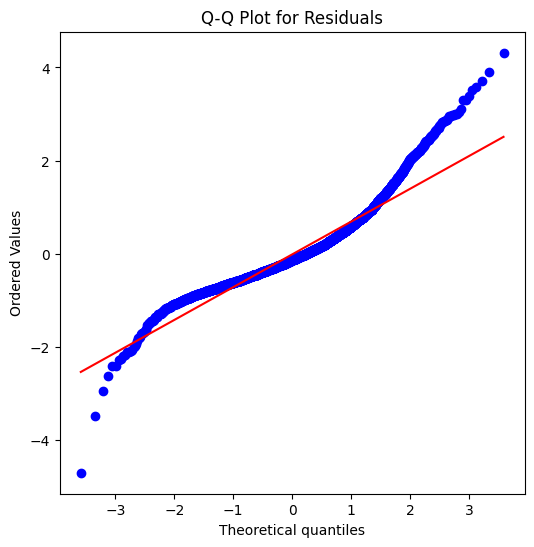

In [31]:
# Calculate residuals
residuals=y_test-y_pred
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

plt.subplot(1,2,2)
sns.histplot(residuals,kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot for Residuals')
plt.show()